# PCA

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import convolve
from sklearn import linear_model, datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM
from sklearn.utils import shuffle
from sklearn.pipeline import Pipeline
from IPython.display import display, clear_output
from matplotlib import animation, rc
from IPython.display import HTML
from sklearn.decomposition import FactorAnalysis, PCA, MiniBatchDictionaryLearning
import requests
import pickle, gzip, numpy

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

%matplotlib inline
#%matplotlib notebook
    
def plot_im_array2(X,S,N,A,title):    
    I = np.ones(((A*(1+S),A*(1+S))))*max(X.flatten())
    k=0
    for i in range(A):
        for j in range(A):
            I[i*(S)+i:(i+1)*S+i,j*S+j:(j+1)*S+j] = X[k,:].reshape((S, S))
            k=k+1
            if(k==N): break
        if(k==N): break
            
    plt.imshow(I, cmap=plt.cm.gray,interpolation=None)
    plt.colorbar()
    plt.xticks(())
    plt.yticks(())
    plt.title(title)
    

In [2]:
# Get Data
r = requests.get('https://s3.amazonaws.com/img-datasets/mnist.pkl.gz')
if(not os.path.exists("mnist.pkl.gz")):
    with open('mnist.pkl.gz', 'wb') as f:
        f.write(r.content)

#Load Data
f = gzip.open('mnist.pkl.gz', 'rb')
train_set, test_set = pickle.load(f,encoding='latin1')

In [3]:
#Pick a digit type
digit=3

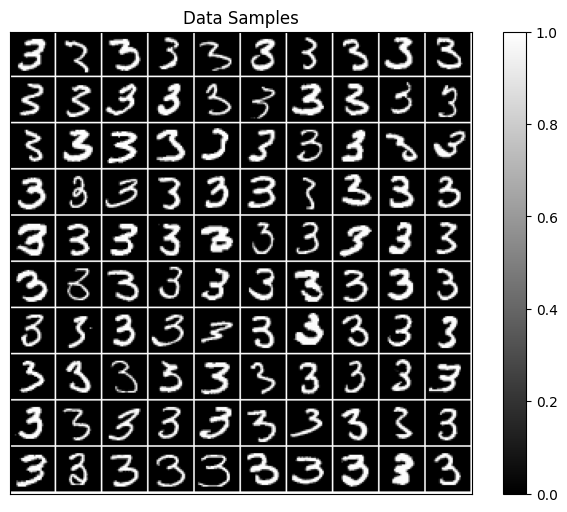

In [4]:
#Show data
Y = train_set[1]
X = train_set[0][Y==digit,:,:]/256.0
X = X.reshape(X.shape[0],X.shape[1]*X.shape[2])
plt.figure(figsize=[8,6]);
plot_im_array2(X[range(0,5000,50),:],28,100,10,"Data Samples")
plt.clim(0,1)
plt.show()



## Learning

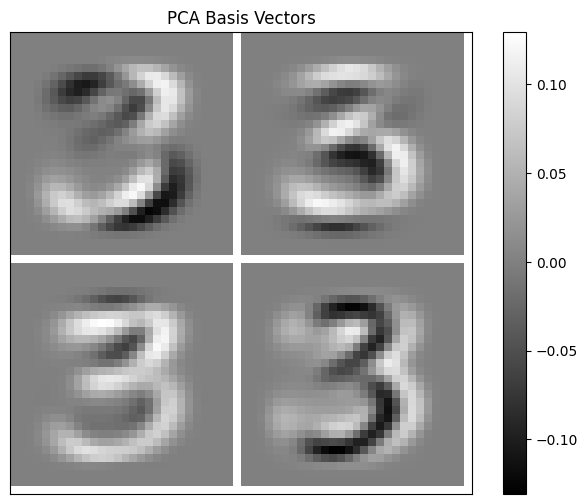

In [5]:
model = PCA(n_components=4, tol=0.01, copy=True, random_state=0)
model.fit(X[:10000,:])
Wfs=model.components_
mus = model.mean_

plt.figure(1,figsize=[8,6])
plot_im_array2(Wfs,28,4,2,"PCA Basis Vectors")
plt.show()

### PCA Reconstruction

In [ ]:
def generate(Z,W,mu):
    return(Z.dot(W) + mu)

def f(z1,z2,z3,z4):
    z = np.array([z1,z2,z3,z4])
    x = generate(z,Wfs,mus).reshape((28,28))
    plt.imshow(x,cmap=plt.cm.gray,interpolation=None,vmin=0,vmax=1)
    plt.colorbar()
    plt.show();

interact(f,z1=(-5.0,5.0),z2=(-5.0,5.0),
         z3=(-5.0,5.0),z4=(-5.0,5.0),
         continuous_update=False);

interactive(children=(FloatSlider(value=0.0, description='z1', max=5.0, min=-5.0), FloatSlider(value=0.0, desc…